In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# Define classes and their labels
classes = {'no_tumor': 0, 'pituitary_tumor': 1, 'glioma_tumor': 2, 'meningioma_tumor': 3}

# Load and preprocess the dataset
X = []
Y = []
for cls, label in classes.items():
    pth = os.path.join("..", "archive", "Training", cls)
    for filename in os.listdir(pth):
        img = cv2.imread(os.path.join(pth, filename), 0)
        img = cv2.resize(img, (200, 200))
        X.append(img.flatten() / 255.0)  # Flatten and normalize the image data
        Y.append(label)
X = np.array(X)
Y = np.array(Y)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'archive\\Training\\no_tumor'

In [ ]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2
)

print("Training samples:", len(xtrain))
print("Testing samples:", len(xtest))
print("====================================")

# Different training percentages to test
training_sizes = [0.2, 0.4, 0.6, 0.8]

# Lists to store test accuracies
rbf_scores = []
linear_scores = []

for size in training_sizes:
    # Create smaller training datasets
    x_small, _, y_small, _ = train_test_split(
        xtrain,
        ytrain,
        train_size=size,
        random_state=10
    )
    
    # Apply PCA
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(x_small)
    pca_test = pca.transform(xtest)

    # ==============================
    # RBF Kernel
    # ==============================

    rbf = SVC(kernel='rbf')
    rbf.fit(pca_train, y_small)
    rbf_train_acc = rbf.score(
        pca_train,
        y_small
    )
    rbf_test_acc = rbf.score(
        pca_test,
        ytest
    )
    rbf_scores.append(rbf_test_acc)

    # ==============================
    # Linear Kernel
    # ==============================

    linear = SVC(kernel='linear')
    linear.fit(
        pca_train,
        y_small
    )
    linear_train_acc = linear.score(
        pca_train,
        y_small
    )
    linear_test_acc = linear.score(
        pca_test,
        ytest
    )
    linear_scores.append(linear_test_acc)

    # Print results neatly

    print("Training size:", size)
    print("Samples:", len(x_small))
    print("RBF Training Accuracy:",
          round(rbf_train_acc,4))
    print("RBF Testing Accuracy:",
          round(rbf_test_acc,4))
    print("Linear Training Accuracy:",
          round(linear_train_acc,4))
    print("Linear Testing Accuracy:",
          round(linear_test_acc,4))
    print("--------------------------------")

# So later prediction cells work without errors
sv = rbf

Training samples: 2296
Testing samples: 574
Training size: 0.2
Samples: 459
RBF Training Accuracy: 0.9434
RBF Testing Accuracy: 0.6777
Linear Training Accuracy: 1.0
Linear Testing Accuracy: 0.7195
--------------------------------
Training size: 0.4
Samples: 918
RBF Training Accuracy: 0.9434
RBF Testing Accuracy: 0.7369
Linear Training Accuracy: 1.0
Linear Testing Accuracy: 0.7474
--------------------------------
Training size: 0.6
Samples: 1377
RBF Training Accuracy: 0.9492
RBF Testing Accuracy: 0.7735
Linear Training Accuracy: 1.0
Linear Testing Accuracy: 0.7857
--------------------------------
Training size: 0.8
Samples: 1836
RBF Training Accuracy: 0.9575
RBF Testing Accuracy: 0.8014
Linear Training Accuracy: 1.0
Linear Testing Accuracy: 0.8101
--------------------------------


In [ ]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM
        
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

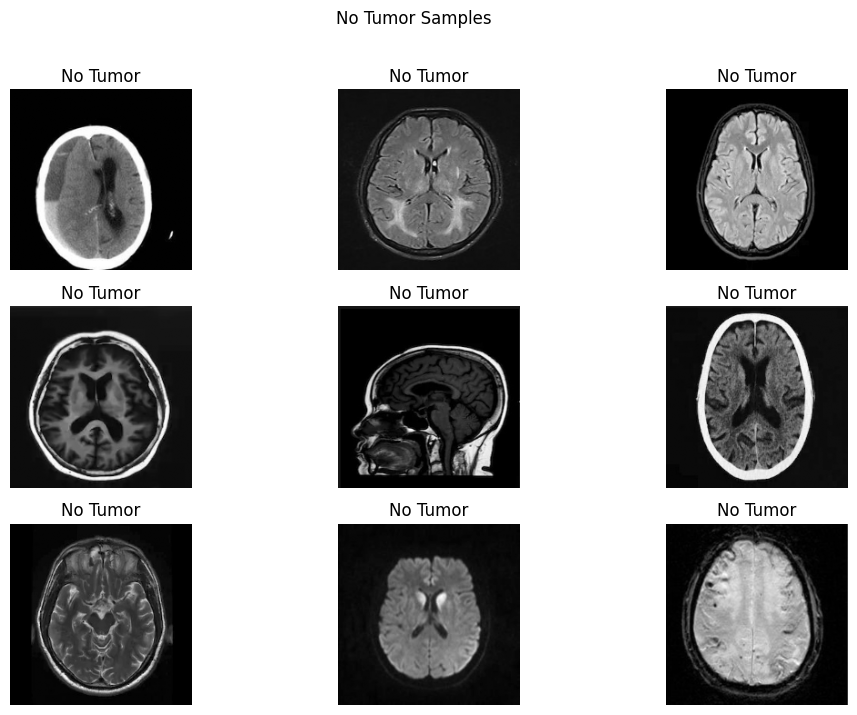

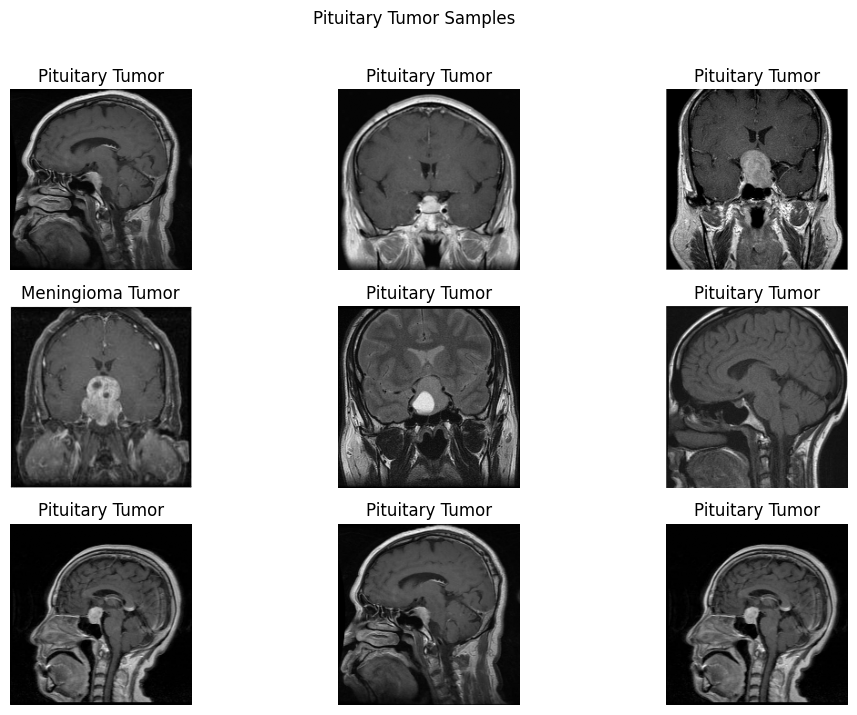

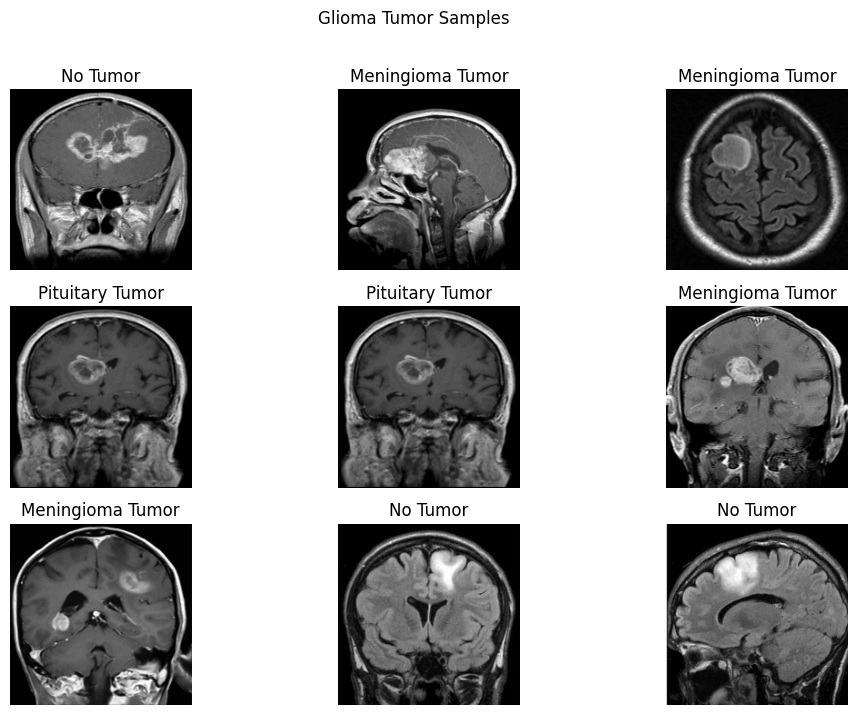

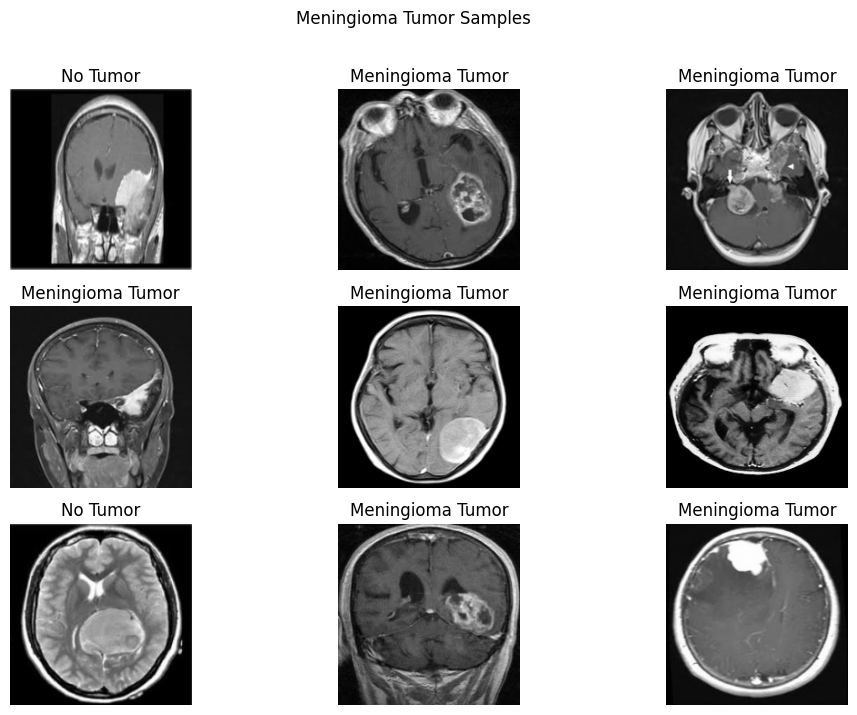

In [ ]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}
# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = os.path.join("archive", "Testing", tumor_folder)
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [ ]:
# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m") 
display(styled_table)


Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


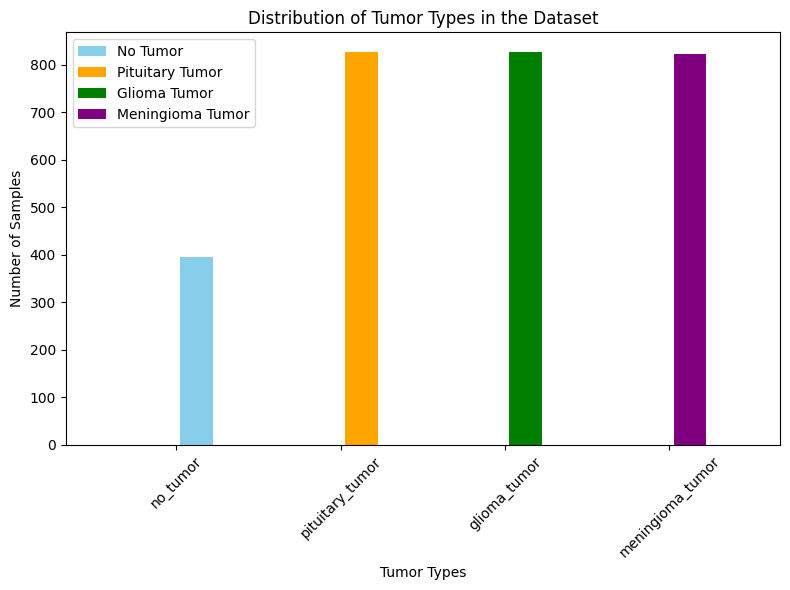

In [ ]:

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show() 

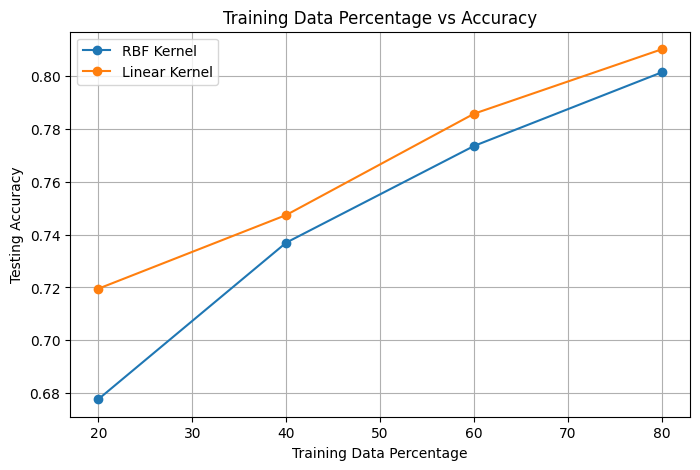

In [ ]:
import matplotlib.pyplot as plt

percentages = [20,40,60,80]
plt.figure(figsize=(8,5))

plt.plot(
    percentages,
    rbf_scores,
    marker='o',
    label='RBF Kernel'
)

plt.plot(
    percentages,
    linear_scores,
    marker='o',
    label='Linear Kernel'
)

plt.xlabel("Training Data Percentage")
plt.ylabel("Testing Accuracy")
plt.title(
    "Training Data Percentage vs Accuracy"
)
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
import numpy as np

# Use the final trained linear model
y_pred = sv.predict(pca_test)

# Accuracy
accuracy = sv.score(pca_test, ytest)

# F1 score (weighted for multiclass)
f1 = f1_score(
    ytest,
    y_pred,
    average='weighted'
)

# Sensitivity
sensitivity = recall_score(
    ytest,
    y_pred,
    average='weighted'
)

# Confusion matrix
cm = confusion_matrix(
    ytest,
    y_pred
)

# Specificity calculation
specificity_list=[]

for i in range(len(cm)):
    TP=cm[i,i]
    FP=np.sum(cm[:,i])-TP
    FN=np.sum(cm[i,:])-TP
    TN=np.sum(cm)-TP-FP-FN
    specificity=TN/(TN+FP)
    specificity_list.append(specificity)

specificity=np.mean(specificity_list)

print("Accuracy:",round(accuracy,4))
print("F1 Score:",round(f1,4))
print("Sensitivity:",round(sensitivity,4))
print("Specificity:",round(specificity,4))

Accuracy: 0.8101
F1 Score: 0.807
Sensitivity: 0.8101
Specificity: 0.9355
